In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

from prophet import Prophet

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

import pickle

Importing plotly failed. Interactive plots will not work.


In [3]:
df = pd.read_csv("../data/cleaned_retail.csv")

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085,United Kingdom,83.4,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085,United Kingdom,100.8,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085,United Kingdom,30.0,2009,12,1,7,Tuesday


In [5]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month', 'Day',
       'Hour', 'Weekday'],
      dtype='object')


In [6]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    dayfirst=True
)


In [7]:
daily_sales = df.groupby(
    df['InvoiceDate'].dt.date
)['TotalPrice'].sum().reset_index()

daily_sales.columns = ['ds', 'y']

In [8]:
daily_sales['ds'] = pd.to_datetime(
    daily_sales['ds']
)

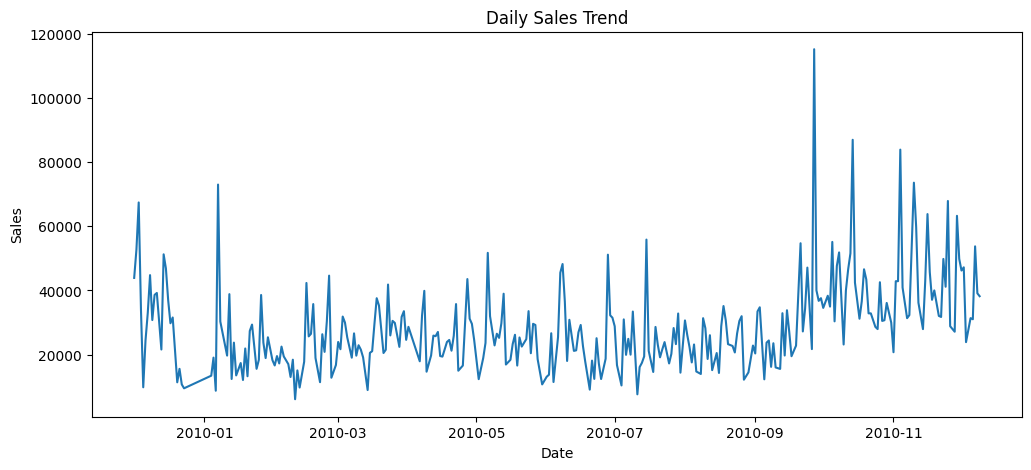

In [9]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales['ds'], daily_sales['y'])

plt.title("Daily Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [10]:
Q1 = daily_sales['y'].quantile(0.25)

Q3 = daily_sales['y'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [11]:
daily_sales = daily_sales[
    (daily_sales['y'] >= lower_bound) &
    (daily_sales['y'] <= upper_bound)
]

In [82]:
train_size = int(len(daily_sales) * 0.8)

train = daily_sales[:train_size]

test = daily_sales[train_size:]

In [83]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=15
)

In [84]:
model.fit(train)

18:17:59 - cmdstanpy - INFO - Chain [1] start processing
18:17:59 - cmdstanpy - INFO - Chain [1] done processing


In [85]:
future = model.make_future_dataframe(
    periods=len(test)
)

In [86]:
forecast = model.predict(future)

In [87]:
predicted = forecast['yhat'].tail(len(test)).values

actual = test['y'].values

In [88]:
mae = mean_absolute_error(
    actual,
    predicted
)

print("MAE:", mae)

MAE: 7621.6670921022


In [89]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

print("RMSE:", rmse)

RMSE: 9183.577327518384


In [90]:
mape = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("MAPE:", mape)

MAPE: 20.98947568913178


In [91]:
accuracy = 100 - mape

print("Approximate Accuracy:", accuracy)

Approximate Accuracy: 79.01052431086822


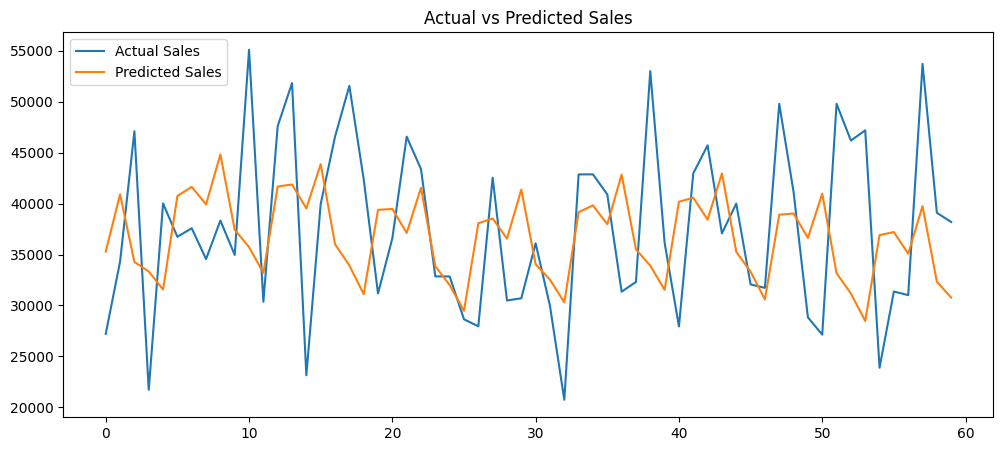

In [92]:
plt.figure(figsize=(12,5))

plt.plot(actual, label='Actual Sales')

plt.plot(predicted, label='Predicted Sales')

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

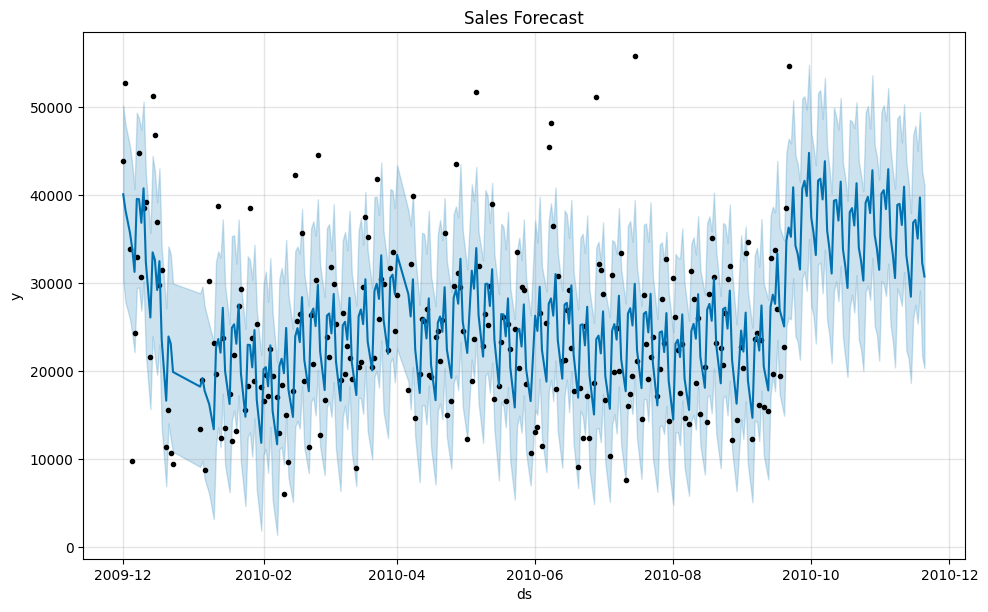

In [104]:
fig1 = model.plot(forecast)

plt.title("Sales Forecast")

plt.savefig(
    "../screenshots/forecast_trend.png",
    bbox_inches='tight'
)

plt.show()

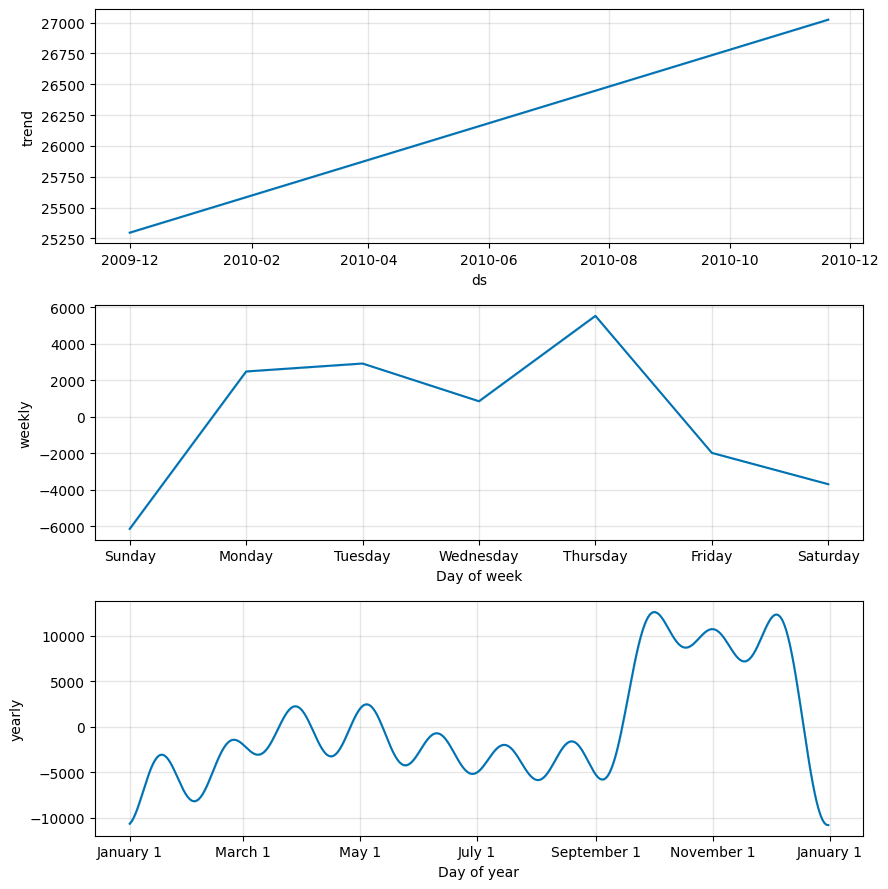

In [102]:
fig2 = model.plot_components(forecast)

plt.savefig(
    "../screenshots/forecast_components.png",
    bbox_inches='tight'
)

plt.show()

In [95]:
inventory = 500

forecasted_demand = forecast['yhat'].tail(1).values[0]

safety_stock = forecasted_demand * 0.2

reorder_quantity = (
    forecasted_demand + safety_stock
) - inventory

reorder_quantity = max(0, reorder_quantity)

print("Forecasted Demand:", forecasted_demand)

print("Current Inventory:", inventory)

print("Safety Stock:", safety_stock)

print("Recommended Reorder Quantity:", reorder_quantity)

Forecasted Demand: 30765.01911136484
Current Inventory: 500
Safety Stock: 6153.003822272968
Recommended Reorder Quantity: 36418.02293363781


In [96]:
if inventory < forecasted_demand * 0.5:
    print("CRITICAL LOW STOCK")

elif inventory < forecasted_demand:
    print("LOW STOCK ALERT")

elif inventory > forecasted_demand * 2:
    print("OVERSTOCK ALERT")

else:
    print("OPTIMAL INVENTORY")

CRITICAL LOW STOCK


In [97]:
inventory_df = pd.DataFrame({
    'Forecasted_Demand': [forecasted_demand],
    'Current_Inventory': [inventory],
    'Safety_Stock': [safety_stock],
    'Reorder_Quantity': [reorder_quantity]
})

inventory_df

,Forecasted_Demand,Current_Inventory,Safety_Stock,Reorder_Quantity
0,30765.019111,500,6153.003822,36418.022934


In [98]:
forecast.to_csv(
    "../reports/forecast_results.csv",
    index=False
)

In [99]:
inventory_df.to_csv(
    "../reports/inventory_recommendations.csv",
    index=False
)

In [100]:
with open(
    "../models/forecast_model.pkl",
    "wb"
) as f:
    
    pickle.dump(model, f)